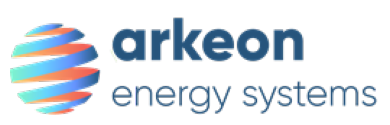

In [61]:
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

startdate = pd.Timestamp("2026-03-02")
enddate   = pd.Timestamp("2026-03-12")
nowdate = pd.Timestamp.now().normalize()

startdate_str = startdate.strftime("%Y-%m-%d")
enddate_str   = enddate.strftime("%Y-%m-%d")
nowdate_str   = nowdate.strftime("%Y-%m-%d")

generate_pdf = 0
generate_html = 1

# Display logo only
fig, ax = plt.subplots(figsize=(4, 2))

try:
    logo_path = Path('../images/logo.png')
    if logo_path.exists():
        img = mpimg.imread(logo_path)
        ax.imshow(img)
    ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Logo', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [62]:
# CELL 1: Import Libraries and Configure Project Paths
# This cell imports all necessary libraries (pandas, numpy, matplotlib) and custom modules
# for data acquisition, API access, and pricing calculations. It also sets up the project
# root path to enable proper module imports from the src/ directory.

import os
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))

from src.acquisition.acquisition import InfluxConfig, run_acquisition
from src.acquisition.endis_api import fetch_consumption_range as get_el_consumption_from_enedis
from src.transform_and_metrics.prix_MWh_elec_TTC import prix_MWh_elec_TTC
from src.transform_and_metrics.prix_MWh_elec_TTC_ENEFFIC import prix_MWh_elec_TTC_ENEFFIC


DATA_DIR = PROJECT_ROOT / "data/energy_flux"
ENEDIS_DIR = DATA_DIR / "ENEDIS"

csv_path = DATA_DIR / f"data_AllData_combined_{startdate_str}_to_{enddate_str}.csv"
json_path = ENEDIS_DIR / f"metering_data_{startdate_str}_to_{enddate_str}.json"

print(f"Configuration du projet...")
# print(f"  Racine du projet : {PROJECT_ROOT}")
# print(f"  Répertoire de données : {DATA_DIR}")
print(f"  Racine et répertoire de données configurés.")
print(f"  Fichiers de données configurés.")
# print(f"    - CSV InfluxDB : {csv_path.name}")
# print(f"    - JSON ENEDIS : {json_path.name}")

Configuration du projet...
  Racine et répertoire de données configurés.
  Fichiers de données configurés.


In [63]:
# CELL 2: Data Acquisition from InfluxDB and ENEDIS API
# This cell handles data import from two sources:
# 1. System data (temperature, energy, heat pump status) from InfluxDB database
# 2. Electricity consumption data from ENEDIS API (French grid operator)
# Both datasets are cached as CSV/JSON files to avoid redundant API calls.
# ENEDIS data is resampled from 5-minute intervals to hourly aggregations.

# IMPORT DATA FROM DATABASE AND ENEDIS API
startdate_influx = startdate - np.timedelta64(1, 'h')
enddate_influx   = enddate - np.timedelta64(1, 'h')

startdate_influx_str = startdate_influx.strftime("%Y-%m-%d %H:%M")
enddate_influx_str   = enddate_influx.strftime("%Y-%m-%d %H:%M")

print(f"Acquisition de données pour la période : {startdate_str} au {enddate_str}")
# print(f"Fichier de données InfluxDB : {csv_path.name}")
# print(f"Fichier de données ENEDIS : {json_path.name}")
print()

# Import system data from database

if os.path.exists(csv_path):
    #print(f"Le fichier données existe déjà. Chargement des données existantes...")
    df = pd.read_csv(csv_path)
else:
    #print(f"Fichier données non trouvé. Lancement de l'acquisition...")
    
    intervals = [{"start_date": startdate_str, "end_date": enddate_str, "description": "Semaine"}]

    result = run_acquisition(
        date_intervals=intervals,
        fields=[
                "TT_ext", "RH_ext", "price",
                "dis_mode", "DIS_BEL_energy_heating",
                "sharky_energy",
                "DIS_CH_A_TT1", "DIS_CH_R_TT1",
                "dis_mode", "DIS_STS_R_TT1", "DIS_STS_A_TT1",],
        use_specific_fields=True,
        output_dir="../data/energy_flux",
        query_mode="daily",
        data_step="1m",
        influx=InfluxConfig(),
    )
    
    # Load the newly created file
    df = pd.read_csv(csv_path)
    #print("Acquisition de données terminée et chargée.")


Acquisition de données pour la période : 2026-03-02 au 2026-03-12



In [64]:
df["DIS_BEL_DELTA"] = df["DIS_BEL_energy_heating"].diff().fillna(0)
df["sharky_energy_delta"] = df["sharky_energy"].diff().fillna(0)
groups = (df['DIS_BEL_DELTA'] != 0)[::-1].cumsum()[::-1]
df['DIS_BEL_DELTA_mean'] = df.groupby(groups)['DIS_BEL_DELTA'].transform('mean')

groups = (df['sharky_energy_delta'] != 0)[::-1].cumsum()[::-1]
df['sharky_energy_delta_mean'] = df.groupby(groups)['sharky_energy_delta'].transform('mean')

df['Q_prod'] = df['DIS_BEL_DELTA_mean']*((df["dis_mode"] == 1) | (df["dis_mode"] == 3)).astype(int) + 0
df["Q_chauffage"] = df["sharky_energy_delta_mean"]
#df["Q_charge"] = (df["DIS_BEL_DELTA_mean"] - df["sharky_energy_delta_mean"]) * (df["dis_mode"] == 3).astype(int) + 0
df["Q_decharge"] = (df["sharky_energy_delta_mean"]) * (df["dis_mode"] == 2).astype(int) + 0
df['_time'] = pd.to_datetime(df['_time']).dt.tz_localize(None)


df["price"] = df["price"].ffill()
df = df.set_index('_time')

df['recharge'] = (df['dis_mode'] == 3)
df['decharge'] = (df['dis_mode'] == 2)
df['direct'] = (df['dis_mode'] == 1)
df['T_stock'] = (df['recharge'] * df['DIS_STS_R_TT1'] + df['decharge'] * df['DIS_STS_A_TT1'])
df['T_stock'] = df['T_stock'].replace(0, np.nan)
if pd.isna(df['T_stock'].iloc[0]):
    df.loc[df.index[0], 'T_stock'] = df[['DIS_STS_R_TT1', 'DIS_STS_A_TT1']].iloc[0].min()
df['T_stock'] = df['T_stock'].ffill()

df['perte_th_stock_W'] = 12.3 * (df['T_stock'] - 22)
df["perte_th_reseau_W_l"] = 30 * 0.44 * ((df['DIS_CH_R_TT1'] + df['DIS_CH_A_TT1']) / 2  - 22)
df["perte_th_reseau_W_s"] = 78 * ((df['DIS_CH_R_TT1'] + df['DIS_CH_A_TT1']) / 2  - 22)
df["perte_th_reseau_W"] = df["perte_th_reseau_W_l"] + df["perte_th_reseau_W_s"]


df["perte_th_stock_Wh"] = df["perte_th_stock_W"] * (1/60)
df["perte_th_reseau_Wh_l"] = df["perte_th_reseau_W_l"] * (1/60)
df["perte_th_reseau_Wh_s"] = df["perte_th_reseau_W_s"] * (1/60)
df["perte_th_reseau_Wh"] = df["perte_th_reseau_W"] * (1/60)

df["Q_charge"] = df["recharge"] * (df['Q_prod'] + df["Q_decharge"] - df["Q_chauffage"] - df["perte_th_reseau_Wh"]/1000)

display(df.iloc[:20])


,table,_start,_stop,DIS_BEL_energy_heating,DIS_CH_A_TT1,DIS_CH_R_TT1,DIS_STS_A_TT1,DIS_STS_R_TT1,RH_ext,TT_ext,...,T_stock,perte_th_stock_W,perte_th_reseau_W_l,perte_th_reseau_W_s,perte_th_reseau_W,perte_th_stock_Wh,perte_th_reseau_Wh_l,perte_th_reseau_Wh_s,perte_th_reseau_Wh,Q_charge
_time,,,,,,,,,,,,,,,,,,,,,
2026-03-02 00:00:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220962.0,39.9,38.2,45.5,43.1,73.7,7.8,...,43.1,259.53,225.06,1329.9,1554.96,4.3255,3.751,22.165,25.916,-0.359249
2026-03-02 00:01:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220963.0,38.9,37.8,45.5,43.0,73.7,7.8,...,43.0,258.30,215.82,1275.3,1491.12,4.3050,3.597,21.255,24.852,-0.358185
2026-03-02 00:02:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220964.0,41.1,38.7,45.5,42.9,73.6,7.8,...,42.9,257.07,236.28,1396.2,1632.48,4.2845,3.938,23.270,27.208,0.139459
2026-03-02 00:03:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220965.0,41.2,38.9,42.4,43.5,73.7,7.7,...,43.5,264.45,238.26,1407.9,1646.16,4.4075,3.971,23.465,27.436,0.139231
2026-03-02 00:04:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220966.0,42.4,40.0,41.9,46.7,73.7,7.7,...,46.7,303.81,253.44,1497.6,1751.04,5.0635,4.224,24.960,29.184,0.137483
2026-03-02 00:05:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220966.0,43.2,41.7,42.8,46.8,73.8,7.7,...,46.8,305.04,269.94,1595.1,1865.04,5.0840,4.499,26.585,31.084,-0.364417
2026-03-02 00:06:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220967.0,45.2,43.7,44.4,47.0,73.9,7.7,...,47.0,307.50,296.34,1751.1,2047.44,5.1250,4.939,29.185,34.124,-0.367457
2026-03-02 00:07:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220968.0,46.4,45.9,45.9,47.1,73.8,7.7,...,47.1,308.73,318.78,1883.7,2202.48,5.1455,5.313,31.395,36.708,0.129959
2026-03-02 00:08:00,0,2026-03-01 23:59:00+00:00,2026-03-02 23:59:00+00:00,220968.0,47.3,46.7,47.0,47.1,73.8,7.8,...,47.1,308.73,330.00,1950.0,2280.00,5.1455,5.500,32.500,38.000,-0.371333


In [65]:
# 1. Ensure datetime format and set index

# 2. Resample using '5min' (not '5m')
# Use a dictionary to apply 'mean' to temps/prices and 'sum' to energy flows
df_resampled = df.resample('20min').agg({
    "TT_ext": "mean",
    "RH_ext": "mean",
    "price": "mean",
    "dis_mode": "first",  # or 'max' if you want to capture any active mode in the interval
    "Q_chauffage": "sum",
    "Q_charge": "sum",
    "Q_decharge": "sum",
    "Q_prod": "sum",
    "perte_th_stock_W": "mean",
    "perte_th_reseau_W": "mean",
    "perte_th_stock_Wh": "sum",
    "perte_th_reseau_Wh_l": "sum",
    "perte_th_reseau_Wh_s": "sum",
    "perte_th_reseau_Wh": "sum"
}).round(2)

In [66]:
print(df_resampled.iloc[:20])
df_resampled.to_csv(DATA_DIR / f"energie_{startdate_str}_to_{enddate_str}_resampled.csv", index=False, float_format='%.2f', sep=';')

                     TT_ext  RH_ext  price  dis_mode  Q_chauffage  Q_charge  \
_time                                                                         
2026-03-02 00:00:00    7.72   73.70  22.25       3.0        14.21      4.08   
2026-03-02 00:20:00    7.76   73.50  17.01       3.0        13.29      3.41   
2026-03-02 00:40:00    7.66   73.60   8.38       1.0        11.00      0.00   
2026-03-02 01:00:00    7.42   74.06  12.25       1.0        13.64      0.00   
2026-03-02 01:20:00    7.18   75.13   7.75       1.0        14.29      0.00   
2026-03-02 01:40:00    7.06   75.90   6.62       1.0        13.57      0.00   
2026-03-02 02:00:00    6.90   76.69  15.99       1.0        13.57      0.00   
2026-03-02 02:20:00    6.88   77.03   7.96       1.0        14.29      0.00   
2026-03-02 02:40:00    6.88   76.85   5.51       1.0        13.57      0.00   
2026-03-02 03:00:00    6.72   77.40   8.98       1.0        13.90      0.00   
2026-03-02 03:20:00    6.71   77.59   7.28       1.0

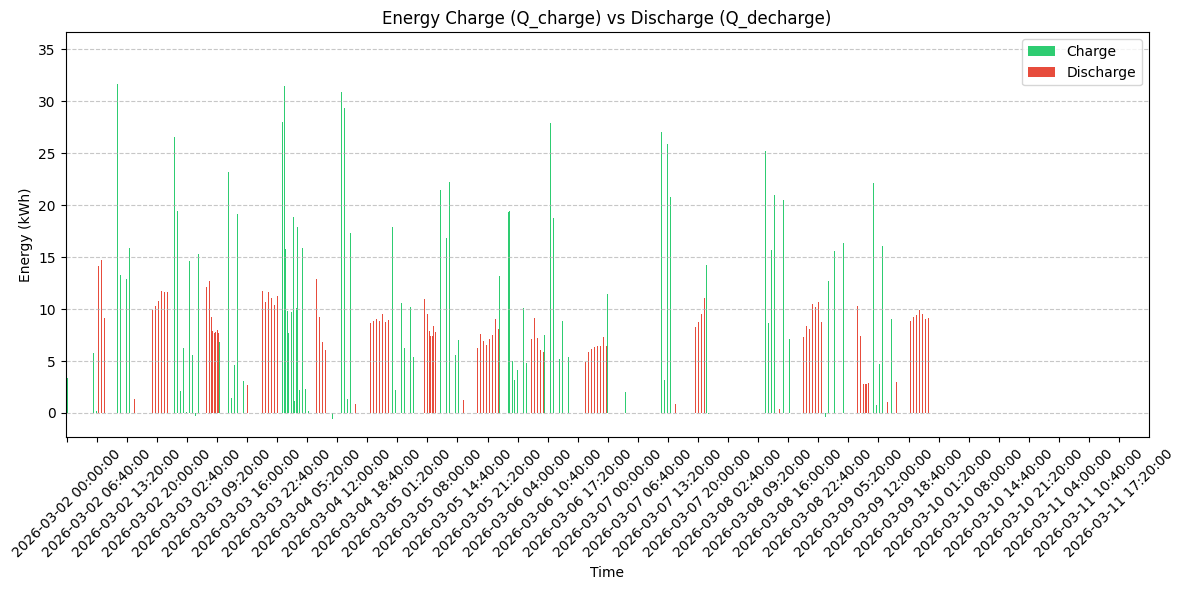

In [67]:
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with '_time' as the index
ax = df_resampled[['Q_charge', 'Q_decharge']].plot(
    kind='bar', 
    figsize=(12, 6), 
    width=0.8,
    color=['#2ecc71', '#e74c3c'] 
)

# --- Simplify X-Ticks ---
# Get the current tick positions and select every 10th one
ticks = ax.get_xticks()
ax.set_xticks(ticks[::20])

# Optionally: ensure the labels match the selected ticks
ax.set_xticklabels(df_resampled.index[::20], rotation=45)
# ------------------------

plt.title('Energy Charge (Q_charge) vs Discharge (Q_decharge)')
plt.xlabel('Time')
plt.ylabel('Energy (kWh)')
plt.xticks(rotation=45) 
plt.legend(["Charge", "Discharge"])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [68]:
print("Energie totale produite (kWh) :", df_resampled['Q_prod'].sum())
print("Energie totale de chauffage (kWh) :", df_resampled['Q_chauffage'].sum())
print("Energie totale de charge (kWh) :", df_resampled['Q_charge'].sum())
print("Energie totale de décharge (kWh) :", df_resampled['Q_decharge'].sum())
print("Rendement :", -df_resampled['Q_decharge'].sum() / df_resampled['Q_charge'].sum() if df_resampled['Q_charge'].sum() != 0 else 0)


Energie totale produite (kWh) : 6996.93
Energie totale de chauffage (kWh) : 6069.91
Energie totale de charge (kWh) : 1863.2
Energie totale de décharge (kWh) : 1399.57
Rendement : -0.7511646629454701


In [69]:
print("Energie totale produite (kWh) :", df['Q_prod'].sum())
print("Energie totale de chauffage (kWh) :", df['Q_chauffage'].sum())
print("Energie totale de charge (kWh) :", df['Q_charge'].sum())
print("Energie totale de décharge (kWh) :", df['Q_decharge'].sum())
print("Perte thermique totale du stock (kWh) :", df['perte_th_stock_Wh'].sum()/1000)
print("Perte thermique linéaire totale du réseau (kWh) :", df['perte_th_reseau_Wh_l'].sum()/1000)
print("Perte thermique singulière totale du réseau (kWh) :", df['perte_th_reseau_Wh_s'].sum()/1000)
print("Perte thermique totale du réseau (kWh) :", df['perte_th_reseau_Wh'].sum()/1000)

print("Perte thermique totale du stock (kW) :", df['perte_th_stock_W'].mean()/1000)
print("Perte thermique totale du réseau (kW) :", df['perte_th_reseau_W'].mean()/1000)
print("T-stock first:", df['T_stock'].iloc[0])
print("T-stock last:", df['T_stock'].iloc[-1])


print("Rendement :", -df['Q_decharge'].sum() / df['Q_charge'].sum() if df['Q_charge'].sum() != 0 else 0)


Energie totale produite (kWh) : 6996.8933034630445
Energie totale de chauffage (kWh) : 6070.0
Energie totale de charge (kWh) : 1863.1773975475783
Energie totale de décharge (kWh) : 1399.6954354070613
Perte thermique totale du stock (kWh) : 91.5307985
Perte thermique linéaire totale du réseau (kWh) : 53.38776299999999
Perte thermique singulière totale du réseau (kWh) : 315.47314500000005
Perte thermique totale du réseau (kWh) : 368.86090800000005
Perte thermique totale du stock (kW) : 0.3846370577111641
Perte thermique totale du réseau (kW) : 1.5508131511456797
T-stock first: 43.1
T-stock last: 45.3
Rendement : -0.7512410988075646


In [70]:
# --- Données d'entrée (kWh sur 7 jours) ---
prod_pac = df['Q_prod'].sum()
conso_bat_directe = df['Q_chauffage'].sum() - df['Q_decharge'].sum()
flux_vers_st = df['Q_prod'].sum() + df['Q_decharge'].sum() - df['Q_chauffage'].sum() - df['perte_th_reseau_Wh'].sum()/1000

pertes_lineiques = df['perte_th_reseau_Wh_l'].sum()/1000              # 30m DN100 isolé
pertes_singulieres = df['perte_th_reseau_Wh_s'].sum()/1000         # vannes + pompes
pertes_ballons = df['perte_th_stock_Wh'].sum()/1000               # 10 stocks de 500L
decharge_st_vers_bat = df['Q_decharge'].sum()        # Énergie récupérée
reliquat_exergie_stock = flux_vers_st - df['Q_decharge'].sum() - df['perte_th_stock_Wh'].sum()/1000     # Énergie non restituée (stockage restant + exergie)

# --- Formatage du texte pour SankeyMATIC ---
sankey_lines = [
    f"PAC [{conso_bat_directe.round(0)}] BAT",
    f"PAC [{flux_vers_st.round(0)}] ST",
    f"PAC [{pertes_lineiques.round(0)}] Pertes linéiques",
    f"PAC [{pertes_singulieres.round(0)}] Pertes singulières",
    f"ST [{decharge_st_vers_bat.round(0)}] BAT",
    f"ST [{pertes_ballons.round(0)}] Pertes stock (ballons)",
    f"ST [{reliquat_exergie_stock.round(0)}] Pertes exergie et stock restant"
]

# --- Affichage ---
print("\n--- COPIER CE TEXTE DANS SANKEYMATIC ---\n")
for line in sankey_lines:
    print(line)
print("\n------------------------------------------")



--- COPIER CE TEXTE DANS SANKEYMATIC ---

PAC [4670.0] BAT
PAC [1958.0] ST
PAC [53.0] Pertes linéiques
PAC [315.0] Pertes singulières
ST [1400.0] BAT
ST [92.0] Pertes stock (ballons)
ST [467.0] Pertes exergie et stock restant

------------------------------------------
